In [1]:
%pip install sympy
%pip install control
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import numpy as np
import sympy
import sim
import time
import struct

In [18]:
def connect(port):
    sim.simxFinish(-1)
    clientID = sim.simxStart('192.168.1.8', port, True, True, 2000, 5)
    print(clientID)
    if clientID == 0: 
        print("Conectado a", port)
        return clientID
    else: 
        print("No se pudo conectar")
        return -1
clientID = connect(500)

0
Conectado a 500


In [ ]:
#Definición de la trayectoria del carro 
_,Carro = sim.simxGetObjectHandle(clientID, 'Carro', sim.simx_opmode_blocking)

print("Carro:", Carro)



_,pos_carro = sim.simxGetObjectPosition(0, Carro, -1, sim.simx_opmode_blocking)
_,ori_carro = sim.simxGetObjectOrientation(0, Carro, -1, sim.simx_opmode_blocking)
print("Posición de Objeto1:", pos_carro)
print("Orientación de Objeto1:", ori_carro)

Pos = -8,-4,0
Ori = 0,0,0
Ori = np.array(Ori) * np.pi / 180  # Convertir a radianes
sim.simxSetObjectPosition(0, Carro, -1, Pos, sim.simx_opmode_blocking)
sim.simxSetObjectOrientation(0, Carro, -1, Ori, sim.simx_opmode_blocking)


Carro: 42
Posición de Objeto1: [-3.9996023178100586, -3.99851655960083, 0.23999954760074615]
Orientación de Objeto1: [9.428092084817763e-07, -2.0046881488156032e-08, -9.920823504216969e-05]


0

DATOS DEL SENSOR

In [ ]:
_, lidar_handle = sim.simxGetObjectHandle(clientID, 'VelodyneVPL16', sim.simx_opmode_blocking)
# Inicio del envío de datos del LIDAR
sim.simxGetStringSignal(clientID, 'VelodyneVPL16', sim.simx_opmode_streaming)

# Lectura de datos del LIDAR 
for i in range(50):
    _, data = sim.simxGetStringSignal(clientID, 'VelodyneVPL16', sim.simx_opmode_buffer)
    if data:
        #Convertir los datos de bytes a puntos
        points = struct.unpack('f' * (len(data) // 4), data)
        print(f"Formato original de los datos recibidos: {data}")
        print(f"Puntos recibidos: {points}")
        points = np.array(points).reshape(-1, 3) # Reorganiza los datos para obtener las coordenadas x, y, z
        print("Datos LIDAR recibidos:")
        print(points)
        break
    time.sleep(0.05)
else:
    print("No se recibieron datos del LIDAR.")

sim.simxFinish(clientID)
print("Conexión cerrada")

#Tareas
# 1. Determinar la cantidad de puntos recibidos por el LIDAR.
# 2. Verficar a qué correspondan los puntos recibidos.
# 3. Tratar de recibir de manera continua los datos del LIDAR.

1
Formato original de los datos recibidos: bytearray(b'\xa4\xf7R@h`T@f\xddI>N\x14`@#Rw@\xab\x84I>}9r@\xef\xd6\x93@\xbd\xffE>c\xa2\x85@16\xb5@\xc2\x19J>EP\x99@}\xa8\xe9@aZM>\xd2\xbd\xbc@\xba\t$A\x94\xc6O>u\xb7\x07A!\x1d\x89A\x07bQ>i\xa0R@7\x81T@\xc1\xdcI>\x06\xaf_@;xw@\x01\x84I>\xc5\xc0q@\xa3\xed\x93@\x12\xffE>\x9dX\x85@\xf1Q\xb5@\x19\x19J>i\xf1\x98@*\xcc\xe9@\xb6YM>\x019\xbc@\xb4"$A\xe5\xc5O>\xc0H\x07A\xf31\x89AMaQ>.IR@\x06\xa2T@|\xdbI>\xbfI_@S\x9ew@\xba\x82I>\rHq@W\x04\x94@\xcb\xfdE>\xd6\x0e\x85@\xb0m\xb5@\xd1\x17J>\x8d\x92\x98@\xd8\xef\xe9@kXM>0\xb4\xbb@\xae;$A\x99\xc4O>\x0c\xda\x06A\xc4F\x89A\xf2_Q>\xf2\xf1Q@\xd6\xc2T@\x93\xd9I>`\xe4^@/\xc4w@\xc0\x81I>T\xcfp@\x0b\x1b\x94@\xe0\xfbE>\x0f\xc5\x84@p\x89\xb5@\xe4\x15J>\xb03\x98@\x86\x13\xea@\x7fVM>^/\xbb@\xa9T$A\xa9\xc2O>Wk\x06A\x96[\x89A\xfc]Q>\xb6\x9aQ@\xa5\xe3T@\t\xd7I>\x18\x7f^@G\xeaw@6\x7fI>\x9aVp@\xbf1\x94@T\xf9E>H{\x84@0\xa5\xb5@[\x13J>\xd3\xd4\x97@47\xea@\xf4SM>\x8c\xaa\xba@\xa3m$A\x19\xc0O>\xa1\xfc\x05Ahp\x89Aa[Q>yCQ@u\x04U@\xe4

CONTROL

Omega: [-11.72393477 -11.55925215 -12.42546224 -10.85772469]
Omega: [ 8.27369527 -1.35806541 -0.73060089  7.64623075]
Omega: [3.22416836 4.10661755 4.54942188 2.78136403]
Omega: [21.39637941 39.54688296 40.12922914 20.81403324]
Omega: [-3.06797551 -4.5775787  -5.24176693 -2.40378728]
Omega: [ 0.29854008 -4.61191421 -5.03670575  0.72333162]
Omega: [-4.78865034  9.88111713  8.5431211  -3.4506543 ]
Omega: [ 6.38252463 -9.42116438 -9.88446028  6.84582054]
Omega: [5.77348669 8.95150698 8.10952756 6.6154661 ]
Omega: [4.23039158 3.84937303 6.8150153  1.26474931]
Omega: [ 3.32542176 16.05058253 15.4395992   3.93640509]
Omega: [-3.49306181 17.71552452 16.69052143 -2.46805872]
Omega: [ 13.63015898 -23.24062383 -24.49135503  14.88089018]
Omega: [ 0.78589769  6.43727688  7.76523349 -0.54205892]
Omega: [4.30097541 6.40792081 5.9733402  4.73555602]
Omega: [11.27513963 18.26905752 17.49056572 12.05363143]
Omega: [29.00658528  8.32429938  8.04678014 29.28410453]
Omega: [-2.50263401  2.74975941  4.2864

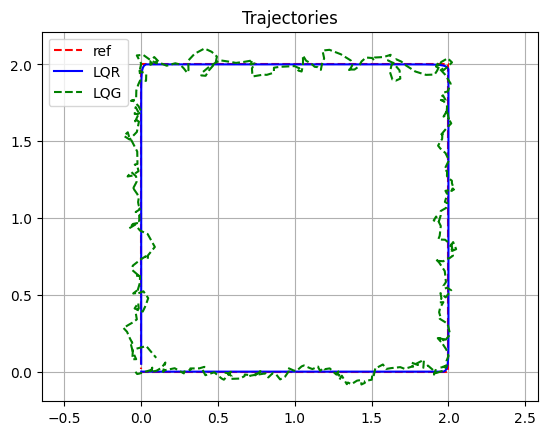

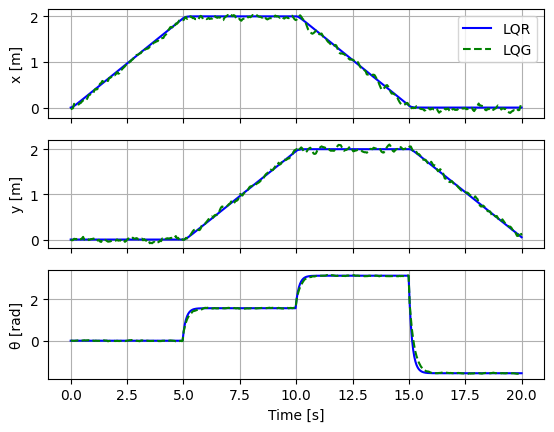

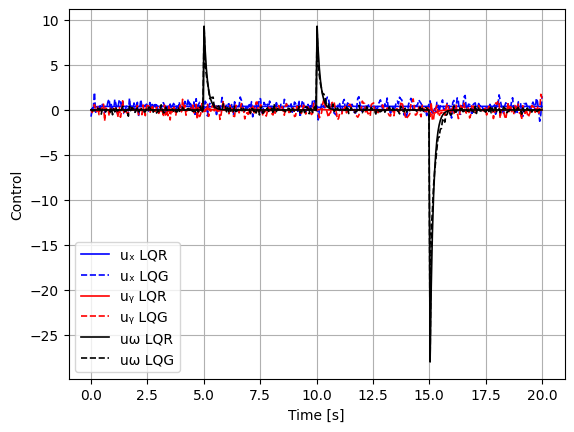

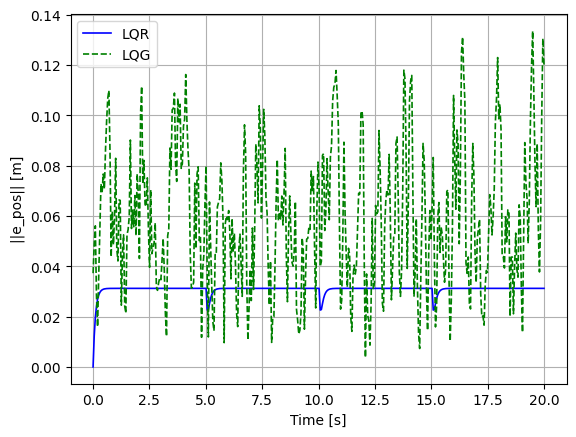

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from control import dlqr, dlqe
from numpy.linalg import pinv

#Verificar si hay giros y el trazado de la ruta

_, joint_fl = sim.simxGetObjectHandle(clientID, 'FL', sim.simx_opmode_blocking)
_, joint_rl = sim.simxGetObjectHandle(clientID, 'RL', sim.simx_opmode_blocking)
_, joint_rr = sim.simxGetObjectHandle(clientID, 'RR', sim.simx_opmode_blocking)
_, joint_fr = sim.simxGetObjectHandle(clientID, 'FR', sim.simx_opmode_blocking)
wheelJoints = [joint_fl, joint_rl, joint_rr, joint_fr]

# -------------------- 1) PARAMETERS & GAINS --------------------
r_wheel = 0.064
l       = 0.1025
J = (1/r_wheel) * np.array([
    [ 1, -1, -(l+l)],
    [ 1,  1,  (l+l)],
    [ 1,  1, -(l+l)],
    [ 1, -1,  (l+l)],
])
J_pinv = pinv(J)

dt = 0.05
tf = 20.0
N  = int(tf/dt)
t  = np.linspace(0, tf, N)

Ad = np.eye(3)
Bd = dt*np.eye(3)
Cd = np.eye(3)

Q = np.diag([10.,10.,5.])
R = np.eye(3)*0.1
K,_,_ = dlqr(Ad, Bd, Q, R)

Qw = np.diag([0.01,0.01,0.005])
Rv = np.diag([0.005,0.005,0.002])
L,_,_ = dlqe(Ad, np.eye(3), Cd, Qw, Rv)  # G = I, not Bd

# -------------------- 2) TRAJECTORY --------------------
def square_traj(tf, dt):
    N = int(tf/dt)
    traj = np.zeros((3,N))
    L = 2.0
    for k in range(N):
        tau = k*dt
        if   tau <  tf/4:
            traj[0,k] = L*(tau)/(tf/4)
        elif tau <  tf/2:
            traj[0,k] = L; traj[1,k] = L*(tau-tf/4)/(tf/4); traj[2,k]=np.pi/2
        elif tau < 3*tf/4:
            traj[0,k] = L - L*(tau-tf/2)/(tf/4); traj[1,k]=L; traj[2,k]=np.pi
        else:
            traj[0,k] = 0; traj[1,k] = L - L*(tau-3*tf/4)/(tf/4); traj[2,k] = -np.pi/2
    return traj

target = square_traj(tf, dt)

# -------------------- 3) STATE & LOGS --------------------
x_lqr  = np.zeros(3)
x_lqg  = np.zeros(3)
xhat   = np.zeros(3)

traj_lqr = np.zeros((3,N))
traj_lqg = np.zeros((3,N))
u_lqr    = np.zeros((3,N))
u_lqg    = np.zeros((3,N))

# -------------------- 4) KINEMATICS UTILITY --------------------
def body_vel(u):
    # here J_pinv@J = I, so body_vel = u
    return u.copy()

# -------------------- 5) SIMULATION --------------------
for k in range(N):
    x_ref = target[:,k]

    # -- LQR (true-state) ---------------------------------
    e_glob = x_ref - x_lqr
    yaw    = x_lqr[2]
    Rth    = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                       [np.sin(yaw),  np.cos(yaw), 0],
                       [0           ,  0           , 1]])
    e_body = Rth.T @ e_glob
    u      = K @ e_body
    v_b    = body_vel(u)
    Rbw    = Rth[:2,:2]
    x_lqr[0:2] += dt*(Rbw @ v_b[0:2])
    x_lqr[2]   += dt*v_b[2]

    traj_lqr[:,k] = x_lqr
    u_lqr[:,k]    = u

    # -- LQG (estimate-based) -----------------------------
    # 1) measurement
    y = x_lqg + np.random.multivariate_normal(np.zeros(3), Rv)

    # 2) observer predict+update using **u2** (not u)
    # we'll compute u2 below, so we do a two-step:
    # predict with last u2, but on first iter u2==u, it's ok
    try:
        prev_u2
    except NameError:
        prev_u2 = u
    xhat = Ad@xhat + Bd@prev_u2 + L@(y - Cd@xhat)

    # 3) compute u2 using **estimated yaw**
    yaw_hat = xhat[2]
    Rth_hat = np.array([[np.cos(yaw_hat), -np.sin(yaw_hat), 0],
                        [np.sin(yaw_hat),  np.cos(yaw_hat), 0],
                        [0              ,  0              , 1]])
    e_glob2 = x_ref - xhat
    e_body2 = Rth_hat.T @ e_glob2
    u2      = K @ e_body2

    # 4) plant under u2
    v_b2 = body_vel(u2)
    x_lqg[0:2] += dt*(Rth[:2,:2] @ v_b2[0:2])  # still world from true yaw
    x_lqg[2]   += dt*v_b2[2]

    traj_lqg[:,k] = x_lqg
    u_lqg[:,k]    = u2
    prev_u2       = u2
    
    #Simulación 
    omega = J @ v_b2
    print(f"Omega: {omega}")
    sim.simxSetJointTargetVelocity(clientID, joint_fl, omega[0], sim.simx_opmode_oneshot)
    sim.simxSetJointTargetVelocity(clientID, joint_fr, omega[1], sim.simx_opmode_oneshot)
    sim.simxSetJointTargetVelocity(clientID, joint_rl, omega[2], sim.simx_opmode_oneshot)
    sim.simxSetJointTargetVelocity(clientID, joint_rr, omega[3], sim.simx_opmode_oneshot)

# -------------------- 6) PLOTS --------------------
plt.figure()
plt.plot(target[0], target[1], 'r--', label='ref')
plt.plot(traj_lqr[0], traj_lqr[1], 'b-',  label='LQR')
plt.plot(traj_lqg[0], traj_lqg[1], 'g--', label='LQG')
plt.axis('equal'); plt.grid(); plt.legend(); plt.title('Trajectories')

fig, axs = plt.subplots(3,1,sharex=True)
labs = ['x [m]','y [m]','θ [rad]']
for i in range(3):
    axs[i].plot(t, traj_lqr[i],  'b-')
    axs[i].plot(t, traj_lqg[i],  'g--')
    axs[i].set_ylabel(labs[i]); axs[i].grid(True)
if True: axs[0].legend(['LQR','LQG'])
axs[2].set_xlabel('Time [s]')

plt.figure()
plt.plot(t, u_lqr[0],'b-', t, u_lqg[0],'b--',
         t, u_lqr[1],'r-', t, u_lqg[1],'r--',
         t, u_lqr[2],'k-', t, u_lqg[2],'k--', linewidth=1.2)
plt.legend(['uₓ LQR','uₓ LQG','uᵧ LQR','uᵧ LQG','uω LQR','uω LQG'])
plt.xlabel('Time [s]'); plt.ylabel('Control'); plt.grid()

err_lqr = np.linalg.norm(traj_lqr[0:2] - target[0:2], axis=0)
err_lqg = np.linalg.norm(traj_lqg[0:2] - target[0:2], axis=0)
plt.figure()
plt.plot(t, err_lqr,'b-', t, err_lqg,'g--', linewidth=1.2)
plt.legend(['LQR','LQG']); plt.xlabel('Time [s]'); plt.ylabel('||e_pos|| [m]'); plt.grid()

plt.show()


In [ ]:
wheelJoints = [joint_fl, joint_rl, joint_rr, joint_fr]

def Mov(clientID, joint_fr, joint_fl, joint_rl, joint_rr, vel):
    for i in range(20):
        if i < 5:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, -vel, sim.simx_opmode_blocking)
            time.sleep(1)
        elif i < 10:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, -vel, sim.simx_opmode_blocking)
            time.sleep(1)
        elif i < 15:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, vel, sim.simx_opmode_blocking)
            time.sleep(1)
        else:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, vel, sim.simx_opmode_blocking)
            time.sleep(1)
Mov(clientID, joint_fr, joint_fl, joint_rl, joint_rr, 3.0)

#Ya mueve la llanta, mirar cómo puedo hacer que haga el cuadrado y después incorporar el control. Además, ver cómo se puede incorporar en una función.